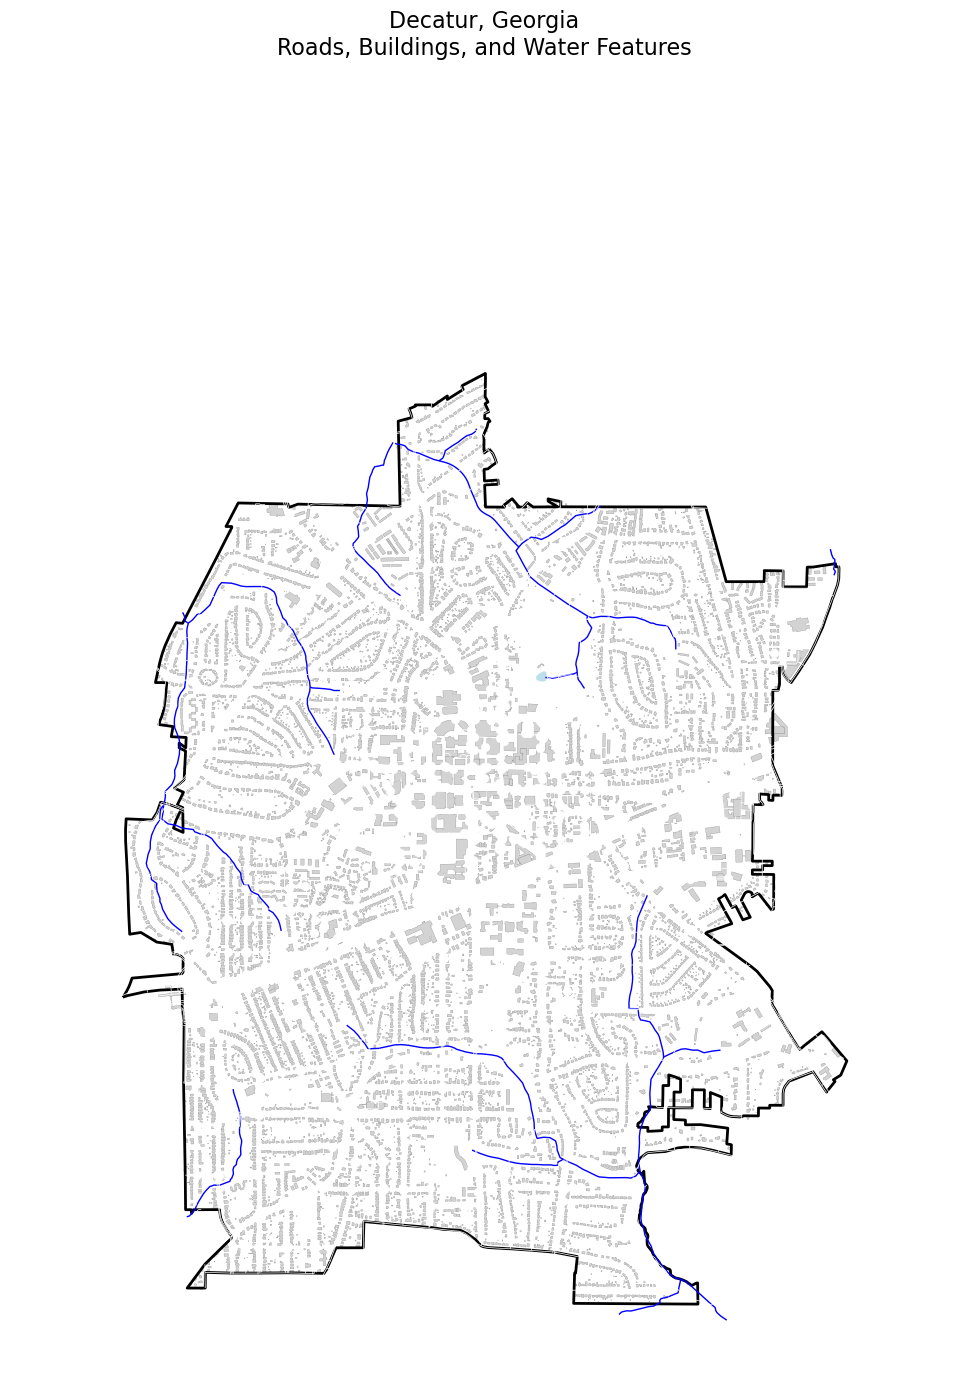

In [3]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# Configure OSMnx
ox.settings.use_cache = True
ox.settings.log_console = True

# Define place
place_name = "Decatur, Dekalb County, Georgia, USA"

# Get city boundary
city = ox.geocode_to_gdf(place_name)

# Roads
roads = ox.features_from_place(
    place_name,
    tags={"highway": True}
)

# Buildings
buildings = ox.features_from_place(
    place_name,
    tags={"building": True}
)

# Water features
water = ox.features_from_place(
    place_name,
    tags={
        "natural": "water"
    }
)

# Additional waterways
waterways = ox.features_from_place(
    place_name,
    tags={
        "waterway": True
    }
)

# Reproject to Web Mercator
city = city.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
buildings = buildings.to_crs(epsg=3857)
water = water.to_crs(epsg=3857)
waterways = waterways.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(14, 14))

# Boundary
city.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

# Water
if not water.empty:
    water.plot(
        ax=ax,
        color="lightblue",
        alpha=0.8
    )

if not waterways.empty:
    waterways.plot(
        ax=ax,
        color="blue",
        linewidth=1
    )

# Buildings
if not buildings.empty:
    buildings.plot(
        ax=ax,
        color="lightgray",
        edgecolor="gray",
        linewidth=0.2
    )

# Roads
roads.plot(
    ax=ax,
    color="white",
    linewidth=0.5
)

ax.set_title(
    "Decatur, Georgia\nRoads, Buildings, and Water Features",
    fontsize=16
)

ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    "decatur_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()